# Current Injection Step Overlay

Extract individual current steps from staircase stimulation trials, align to step onset, and plot overlaid.
- **Top subplot**: membrane potential (mV)
- **Bottom subplot**: command current (pA)
- Traces colored by step amplitude (black → light blue)

In [1]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import h5py
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# Add project root to path so we can import project modules
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
# ── Set path to your trial HDF5 file ──
H5_PATH = Path(r"D:\data\fre021\fre021_ss41068-gfp_20260408_121052.h5")

## Load data

Works with both trial-based (`_trials.h5`) and continuous (`.h5`) recordings.

In [3]:
with h5py.File(H5_PATH, "r") as f:
    sample_rate = int(f["metadata"].attrs["sample_rate"])
    channel_names = list(f["metadata/channel_names"][:])
    display_scales = f["metadata/display_scales"][:]
    units = list(f["metadata/units"][:])

    # Detect file type: trial-based vs continuous
    trial_keys = sorted(k for k in f.keys() if k.startswith("trial_"))

    if trial_keys:
        # Trial-based file: one array per trial, grouped by stimulus name
        file_type = "trial"
        sweeps_by_name = defaultdict(list)
        for key in trial_keys:
            grp = f[key]
            sweeps_by_name[grp.attrs["stimulus_name"]].append(
                grp["analog_input"][:]
            )
    else:
        # Continuous file: single long recording in /data/analog_input
        file_type = "continuous"
        sweeps_by_name = {"recording": [f["data/analog_input"][:]]}

print(f"File type: {file_type}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Channels: {channel_names}")
for name, sweeps in sweeps_by_name.items():
    print(f"  {name}: {len(sweeps)} sweep(s), shape {sweeps[0].shape}")

File type: continuous
Sample rate: 20000 Hz
Channels: [b'ScAmpOut', b'RawAmpOut', b'AmpCmd', b'Camera', b'TTLLoopback']
  recording: 1 sweep(s), shape (5, 3673800)


## Detect current injection steps and group into staircases

In [4]:
CMD_CH = 2  # AmpCmd channel index
MIN_STEP_MS = 50  # minimum plateau duration to count as a real step
MIN_TRANSITION_PA = 10  # ignore transitions smaller than this
MIN_AMP_PA = 10  # ignore plateaus with amplitude below this
MAX_GAP_MS = 1000  # max silence between steps to be considered part of the same staircase


def ms_to_samples(ms, sr=sample_rate):
    return max(0, int(ms / 1000.0 * sr))


def detect_steps(sweep, cmd_ch=CMD_CH, min_step_ms=MIN_STEP_MS,
                 min_transition_pA=MIN_TRANSITION_PA, min_amp_pA=MIN_AMP_PA,
                 sr=sample_rate):
    """Detect current injection steps from the AmpCmd channel.

    Uses median filtering to suppress transition artifacts, then finds
    stable plateaus separated by transitions of at least min_transition_pA
    and with amplitude at least min_amp_pA.

    Returns list of dicts: {onset, offset, amplitude_pA}
    where onset/offset are sample indices.
    """
    from scipy.ndimage import median_filter

    cmd_pA = sweep[cmd_ch] * display_scales[cmd_ch]

    # Median filter to clean up transition artifacts (1 ms kernel)
    kernel = max(3, ms_to_samples(1.0, sr) | 1)  # ensure odd
    cmd_smooth = median_filter(cmd_pA, size=kernel)

    # Round to nearest step size to collapse noise
    step_size = min_transition_pA
    cmd_rounded = np.round(cmd_smooth / step_size) * step_size

    # Find transitions that are at least min_transition_pA
    diff = np.diff(cmd_rounded)
    change_idx = np.nonzero(np.abs(diff) >= min_transition_pA)[0] + 1
    boundaries = np.concatenate([[0], change_idx, [len(cmd_rounded)]])

    min_samples = ms_to_samples(min_step_ms, sr)

    steps = []
    for i in range(len(boundaries) - 1):
        onset = int(boundaries[i])
        offset = int(boundaries[i + 1])
        duration = offset - onset
        amp = float(np.median(cmd_rounded[onset:offset]))

        # Only keep plateaus that are long enough and large enough
        if duration >= min_samples and abs(amp) >= min_amp_pA:
            steps.append({"onset": onset, "offset": offset, "amplitude_pA": amp})

    return steps


def group_into_staircases(steps, max_gap_ms=MAX_GAP_MS, sr=sample_rate):
    """Group detected steps into staircases.

    Steps separated by more than max_gap_ms of baseline are split into
    separate staircases.
    """
    max_gap_samples = ms_to_samples(max_gap_ms, sr)

    if not steps:
        return []

    staircases = []
    current = [steps[0]]

    for prev, s in zip(steps[:-1], steps[1:]):
        gap = s["onset"] - prev["offset"]
        if gap > max_gap_samples:
            staircases.append(current)
            current = [s]
        else:
            current.append(s)
    staircases.append(current)

    return staircases


# Detect and group for each sweep set
all_staircases = {}
for name, sweeps in sweeps_by_name.items():
    steps = detect_steps(sweeps[0])
    staircases = group_into_staircases(steps)
    all_staircases[name] = staircases

    print(f"\n{name}: {len(staircases)} staircase(s) found")
    for sc_idx, sc in enumerate(staircases):
        amps = [s["amplitude_pA"] for s in sc]
        t_start = sc[0]["onset"] / sample_rate
        t_end = sc[-1]["offset"] / sample_rate
        print(f"  Staircase {sc_idx}: {len(sc)} steps, "
              f"{min(amps):+.0f} to {max(amps):+.0f} pA, "
              f"t = {t_start:.2f}–{t_end:.2f} s")


recording: 3 staircase(s) found
  Staircase 0: 4 steps, -100 to +100 pA, t = 13.42–16.72 s
  Staircase 1: 40 steps, -100 to +100 pA, t = 24.20–59.00 s
  Staircase 2: 40 steps, -50 to +150 pA, t = 101.46–136.26 s


## Select a staircase and extract step segments aligned to onset

In [5]:
VM_CH = 0   # ScAmpOut → membrane potential
PAD_MS = 100  # ms of baseline to show before each step onset

# ── Pick which staircase to plot ──
SWEEP_NAME = list(all_staircases.keys())[0]  # first stimulus group
STAIRCASE_IDX = 1  # which staircase within that group


def extract_steps(sweep, staircase, pad_ms=PAD_MS, sr=sample_rate):
    """Extract Vm and I_cmd segments for each step, aligned to onset.

    Returns list of dicts: {amplitude_pA, time_ms, vm_mV, i_cmd_pA}
    Time axis: t=0 at step onset, negative values = pre-step baseline.
    """
    pad_samples = ms_to_samples(pad_ms, sr)
    n_total = sweep.shape[1]
    segments = []

    for step in staircase:
        onset = step["onset"]
        offset = step["offset"]

        seg_start = max(0, onset - pad_samples)
        seg_end = min(n_total, offset + pad_samples)

        vm = sweep[VM_CH, seg_start:seg_end] * display_scales[VM_CH]
        i_cmd = sweep[CMD_CH, seg_start:seg_end] * display_scales[CMD_CH]
        t_ms = (np.arange(seg_end - seg_start) - (onset - seg_start)) / sr * 1000.0

        segments.append({
            "amplitude_pA": step["amplitude_pA"],
            "time_ms": t_ms,
            "vm_mV": vm,
            "i_cmd_pA": i_cmd,
        })

    return segments


# Extract from all sweeps of the selected stimulus
staircase_template = all_staircases[SWEEP_NAME][STAIRCASE_IDX]
all_segments = [
    extract_steps(sw, staircase_template)
    for sw in sweeps_by_name[SWEEP_NAME]
]
print(f"Extracting staircase {STAIRCASE_IDX} from '{SWEEP_NAME}': "
      f"{len(staircase_template)} steps × {len(all_segments)} sweep(s)")

Extracting staircase 1 from 'recording': 40 steps × 1 sweep(s)


## Plot overlaid step responses

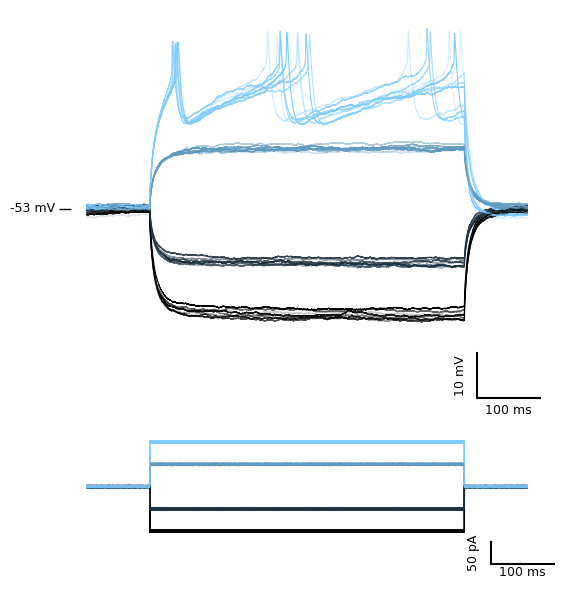

In [11]:
# Black → light blue colormap
CMAP = mcolors.LinearSegmentedColormap.from_list(
    "black_lightblue", [(0, 0, 0), (0.5, 0.8, 1.0)]
)


def add_scalebar(ax, x_size, x_unit, y_size, y_unit, loc="lower right",
                 x_pad=0.02, y_pad=0.05):
    """Add an L-shaped scale bar outside the data range."""
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_range = xlim[1] - xlim[0]
    y_range = ylim[1] - ylim[0]

    # Place below and to the right of the data area
    x0 = xlim[1] - x_pad * x_range - x_size
    y0 = ylim[0] - y_pad * y_range - y_size

    # Horizontal bar
    ax.plot([x0, x0 + x_size], [y0, y0], color="black", linewidth=1.5, clip_on=False)
    # Vertical bar
    ax.plot([x0, x0], [y0, y0 + y_size], color="black", linewidth=1.5, clip_on=False)
    # Labels
    ax.text(x0 + x_size / 2, y0 - 0.02 * y_range, f"{x_size} {x_unit}",
            ha="center", va="top", fontsize=9)
    ax.text(x0 - 0.02 * x_range, y0 + y_size / 2, f"{y_size} {y_unit}",
            ha="right", va="center", fontsize=9, rotation=90)


def plot_step_overlay(segment_lists, title="", figsize=(6,6),
                      vm_scalebar=(100, "ms", 10, "mV"),
                      cmd_scalebar=(100, "ms", 50, "pA")):
    """Plot overlaid step responses colored by injection amplitude.

    Parameters
    ----------
    segment_lists : list of list of dict
        Each inner list is one sweep's worth of step segments.
    vm_scalebar : tuple
        (x_size, x_unit, y_size, y_unit) for the Vm axes.
    cmd_scalebar : tuple
        (x_size, x_unit, y_size, y_unit) for the I_cmd axes.
    """
    all_amps = sorted({
        seg["amplitude_pA"]
        for sweep_segs in segment_lists
        for seg in sweep_segs
    })
    norm = mcolors.Normalize(vmin=min(all_amps), vmax=max(all_amps))

    fig, (ax_vm, ax_cmd) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )
    alphaIDX = 0
    for sweep_segs in segment_lists:
        for seg in sweep_segs:
            color = CMAP(norm(seg["amplitude_pA"]))
            ax_vm.plot(seg["time_ms"], seg["vm_mV"], color=color, linewidth=0.8, alpha=1-alphaIDX)
            ax_cmd.plot(seg["time_ms"], seg["i_cmd_pA"], color=color, linewidth=0.8, alpha=0.8)
            alphaIDX+=.1
            if alphaIDX >= 1:
                alphaIDX = 0
        alphaIDX=0

    # Remove spines, ticks, and grid
    for ax in (ax_vm, ax_cmd):
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Estimate resting membrane potential from the pre-step baseline
    baseline_vals = []
    for sweep_segs in segment_lists:
        for seg in sweep_segs:
            mask = seg["time_ms"] < 0
            if np.any(mask):
                baseline_vals.append(np.median(seg["vm_mV"][mask]))
    rmp = np.median(baseline_vals)
    rmp_rounded = round(rmp)

    # Add RMP tick on the left y-axis
    xlim = ax_vm.get_xlim()
    tick_x = xlim[0]
    ax_vm.plot(tick_x, rmp, marker="_", markersize=8, color="black", clip_on=False)
    ax_vm.text(tick_x - 0.02 * (xlim[1] - xlim[0]), rmp, f"{rmp_rounded} mV",
               ha="right", va="center", fontsize=9)

    # Scale bars — placed below each subplot so they don't overlap traces
    add_scalebar(ax_vm, *vm_scalebar)
    add_scalebar(ax_cmd, *cmd_scalebar)

    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold")

    fig.tight_layout()
    return fig, (ax_vm, ax_cmd)


plot_step_overlay(all_segments, title=None)
plt.show()